<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/analisis_objetivo_4tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Detallado del Objetivo Específico 4: Comparación de Modelos Tradicionales y Supervisados

Este notebook presenta un análisis exhaustivo del Objetivo Específico 4 de la tesis "Uso de modelos supervisados por analistas financieros en la predicción de precios de acciones de Google y Amazon". El objetivo se centra en "Evaluar la precisión de los modelos supervisados seleccionados (Random Forest y Gradient Boosting) en comparación con modelos tradicionales (ARIMA y GARCH) para la predicción de precios de acciones financieras".

Se explorará el dataset proporcionado, se implementarán y compararán modelos tradicionales de series de tiempo (ARIMA, GARCH) con modelos de Machine Learning supervisados (Random Forest, Gradient Boosting), y se analizarán sus rendimientos y las implicaciones financieras.

## Fase 1: Análisis del Documento PDF y Contexto del Objetivo Específico 4

El Objetivo Específico 4 busca comparar la precisión de los modelos supervisados (Random Forest y Gradient Boosting) con modelos tradicionales (ARIMA y GARCH) en la predicción de precios de acciones financieras. Esto implica una evaluación rigurosa de las métricas de rendimiento para determinar la superioridad de un enfoque sobre otro.

**Objetivo Específico 4:** "Evaluar la precisión de los modelos supervisados seleccionados (Random Forest y Gradient Boosting) en comparación con modelos tradicionales (ARIMA y GARCH) para la predicción de precios de acciones financieras."

## Fase 2: Preparación del Dataset para el Objetivo 4

Cargamos el dataset `dataset_completo_google_amazon.csv` y realizamos la preparación necesaria, incluyendo la creación de características de `lag` y la división de los datos en conjuntos de entrenamiento y prueba para asegurar una evaluación justa de los modelos.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = "dataset_completo_google_amazon.csv"
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date")

# Create lagged features
df["GOOGL_Close_Lag1"] = df["GOOGL_Close"].shift(1)
df["AMZN_Close_Lag1"] = df["AMZN_Close"].shift(1)
df = df.dropna() # Drop rows with NaN values created by shifting

features = ["GOOGL_Close_Lag1", "AMZN_Close_Lag1", "Treasury_10Y", "VIX", "SP500", "NASDAQ", "Inflacion_T5YIE"]
target_googl = "GOOGL_Close"
target_amzn = "AMZN_Close"

X = df[features]
y_googl = df[target_googl]
y_amzn = df[target_amzn]

# Split data into training and testing sets (80% train, 20% test)
X_train_googl, X_test_googl, y_train_googl, y_test_googl = train_test_split(X, y_googl, test_size=0.2, random_state=42)
X_train_amzn, X_test_amzn, y_train_amzn, y_test_amzn = train_test_split(X, y_amzn, test_size=0.2, random_state=42)

# Save the prepared data for subsequent steps
X_train_googl.to_csv("X_train_googl.csv", index=False)
X_test_googl.to_csv("X_test_googl.csv", index=False)
y_train_googl.to_csv("y_train_googl.csv", index=False)
y_test_googl.to_csv("y_test_googl.csv", index=False)

X_train_amzn.to_csv("X_train_amzn.csv", index=False)
X_test_amzn.to_csv("X_test_amzn.csv", index=False)
y_train_amzn.to_csv("y_train_amzn.csv", index=False)
y_test_amzn.to_csv("y_test_amzn.csv", index=False)

# Also save the full processed dataframe for traditional models that might need the date index
df.to_csv("processed_data_for_obj4.csv", index=False)

print("Data preparation complete. Training and testing sets created.")


Data preparation complete. Training and testing sets created.


## Fase 3: Implementación de Modelos Tradicionales (ARIMA y GARCH)

Se implementarán modelos ARIMA para la predicción de precios y se explorará la aplicación de GARCH para la volatilidad, con una simplificación para la predicción de precios para fines comparativos. Se utilizarán las métricas MSE y R2 para evaluar su rendimiento.

In [4]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 14.6 MB/s eta 0:00:00


In [7]:
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Re-load the full processed dataframe for traditional models that need the date index
df_full = pd.read_csv("processed_data_for_obj4.csv")
df_full["Date"] = pd.to_datetime(df_full["Date"])
df_full = df_full.set_index("Date")

train_size = int(len(df_full) * 0.8)
train_data = df_full.iloc[:train_size]
test_data = df_full.iloc[train_size:]

traditional_results = {}

# --- ARIMA Models ---
print("--- ARIMA Models ---")

# ARIMA for GOOGL
print("Fitting ARIMA for GOOGL...")
model_arima_googl = ARIMA(train_data["GOOGL_Close"], order=(5,1,0))
model_arima_googl_fit = model_arima_googl.fit()
forecast_arima_googl = model_arima_googl_fit.predict(start=len(train_data), end=len(df_full)-1)
mse_arima_googl = mean_squared_error(test_data["GOOGL_Close"], forecast_arima_googl)
r2_arima_googl = r2_score(test_data["GOOGL_Close"], forecast_arima_googl)
traditional_results["GOOGL_ARIMA"] = {"MSE": mse_arima_googl, "R2": r2_arima_googl}
print(f"ARIMA (GOOGL) - MSE: {mse_arima_googl:.4f}, R2: {r2_arima_googl:.4f}")

# ARIMA for AMZN
print("Fitting ARIMA for AMZN...")
model_arima_amzn = ARIMA(train_data["AMZN_Close"], order=(5,1,0))
model_arima_amzn_fit = model_arima_amzn.fit()
forecast_arima_amzn = model_arima_amzn_fit.predict(start=len(train_data), end=len(df_full)-1)
mse_arima_amzn = mean_squared_error(test_data["AMZN_Close"], forecast_arima_amzn)
r2_arima_amzn = r2_score(test_data["AMZN_Close"], forecast_arima_amzn)
traditional_results["AMZN_ARIMA"] = {"MSE": mse_arima_amzn, "R2": r2_arima_amzn}
print(f"ARIMA (AMZN) - MSE: {mse_arima_amzn:.4f}, R2: {r2_arima_amzn:.4f}")

# --- GARCH Models (Simplified Price Prediction for Comparison) ---
print("--- GARCH Models (Simplified Price Prediction) ---")

train_data["GOOGL_Returns"] = 100 * train_data["GOOGL_Close"].pct_change().dropna()
test_data["GOOGL_Returns"] = 100 * test_data["GOOGL_Close"].pct_change().dropna()
train_data["AMZN_Returns"] = 100 * train_data["AMZN_Close"].pct_change().dropna()
test_data["AMZN_Returns"] = 100 * test_data["AMZN_Close"].pct_change().dropna()

# GARCH for GOOGL (using a simple mean model for price prediction)
googl_last_price = train_data["GOOGL_Close"].iloc[-1]
googl_predicted_returns = np.zeros(len(test_data)) # Assuming mean return is 0
googl_predicted_prices_garch = googl_last_price * (1 + googl_predicted_returns / 100).cumsum()
mse_garch_googl = mean_squared_error(test_data["GOOGL_Close"].iloc[1:], googl_predicted_prices_garch[:-1])
r2_garch_googl = r2_score(test_data["GOOGL_Close"].iloc[1:], googl_predicted_prices_garch[:-1])
traditional_results["GOOGL_GARCH"] = {"MSE": mse_garch_googl, "R2": r2_garch_googl}
print(f"GARCH (GOOGL - Simplified Price Pred.) - MSE: {mse_garch_googl:.4f}, R2: {r2_garch_googl:.4f}")

# GARCH for AMZN Returns
amzn_last_price = train_data["AMZN_Close"].iloc[-1]
amzn_predicted_returns = np.zeros(len(test_data)) # Assuming mean return is 0
amzn_predicted_prices_garch = amzn_last_price * (1 + amzn_predicted_returns / 100).cumsum()
mse_garch_amzn = mean_squared_error(test_data["AMZN_Close"].iloc[1:], amzn_predicted_prices_garch[:-1])
r2_garch_amzn = r2_score(test_data["AMZN_Close"].iloc[1:], amzn_predicted_prices_garch[:-1])
traditional_results["AMZN_GARCH"] = {"MSE": mse_garch_amzn, "R2": r2_garch_amzn}
print(f"GARCH (AMZN - Simplified Price Pred.) - MSE: {mse_garch_amzn:.4f}, R2: {r2_garch_amzn:.4f}")

# Save traditional results for comparison
with open("traditional_model_results.txt", "w") as f:
    for model, metrics in traditional_results.items():
        #f.write(f"{model} - MSE: {metrics["MSE"]:.4f}, R2: {metrics["R2"]:.4f}")
        f.write(f'{model} - MSE: {metrics["MSE"]:.4f}, R2: {metrics["R2"]:.4f}')
print("Traditional model results saved to traditional_model_results.txt")


--- ARIMA Models ---
Fitting ARIMA for GOOGL...
ARIMA (GOOGL) - MSE: 1115.8896, R2: -6.7412
Fitting ARIMA for AMZN...
ARIMA (AMZN) - MSE: 415.8768, R2: -0.8550
--- GARCH Models (Simplified Price Prediction) ---
GARCH (GOOGL - Simplified Price Pred.) - MSE: 248003613.8837, R2: -1764465.0516
GARCH (AMZN - Simplified Price Pred.) - MSE: 402330820.3007, R2: -1792172.8678
Traditional model results saved to traditional_model_results.txt


## Fase 4: Implementación y Re-evaluación de Modelos Supervisados

Se re-evaluarán los modelos Random Forest y Gradient Boosting, utilizando los mismos conjuntos de datos de entrenamiento y prueba para una comparación justa.

In [9]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load prepared data (from Phase 2)
X_train_googl = pd.read_csv("X_train_googl.csv")
X_test_googl = pd.read_csv("X_test_googl.csv")
y_train_googl = pd.read_csv("y_train_googl.csv").squeeze()
y_test_googl = pd.read_csv("y_test_googl.csv").squeeze()

X_train_amzn = pd.read_csv("X_train_amzn.csv")
X_test_amzn = pd.read_csv("X_test_amzn.csv")
y_train_amzn = pd.read_csv("y_train_amzn.csv").squeeze()
y_test_amzn = pd.read_csv("y_test_amzn.csv").squeeze()

supervised_results = {}

# --- Google Stock Prediction ---
print("--- Re-evaluating Supervised Models for Google ---")
rf_googl = RandomForestRegressor(n_estimators=100, random_state=42)
rf_googl.fit(X_train_googl, y_train_googl)
y_pred_rf_googl = rf_googl.predict(X_test_googl)
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)
supervised_results["GOOGL_RF"] = {"MSE": mse_rf_googl, "R2": r2_rf_googl}
print(f"Random Forest (Google) - MSE: {mse_rf_googl:.4f}, R2: {r2_rf_googl:.4f}")

gb_googl = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_googl.fit(X_train_googl, y_train_googl)
y_pred_gb_googl = gb_googl.predict(X_test_googl)
mse_gb_googl = mean_squared_error(y_test_googl, y_pred_gb_googl)
r2_gb_googl = r2_score(y_test_googl, y_pred_gb_googl)
supervised_results["GOOGL_GB"] = {"MSE": mse_gb_googl, "R2": r2_gb_googl}
print(f"Gradient Boosting (Google) - MSE: {mse_gb_googl:.4f}, R2: {r2_gb_googl:.4f}")

# --- Amazon Stock Prediction ---
print("--- Re-evaluating Supervised Models for Amazon ---")
rf_amzn = RandomForestRegressor(n_estimators=100, random_state=42)
rf_amzn.fit(X_train_amzn, y_train_amzn)
y_pred_rf_amzn = rf_amzn.predict(X_test_amzn)
mse_rf_amzn = mean_squared_error(y_test_amzn, y_pred_rf_amzn)
r2_rf_amzn = r2_score(y_test_amzn, y_pred_rf_amzn)
supervised_results["AMZN_RF"] = {"MSE": mse_rf_amzn, "R2": r2_rf_amzn}
print(f"Random Forest (Amazon) - MSE: {mse_rf_amzn:.4f}, R2: {r2_rf_amzn:.4f}")

gb_amzn = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_amzn.fit(X_train_amzn, y_train_amzn)
y_pred_gb_amzn = gb_amzn.predict(X_test_amzn)
mse_gb_amzn = mean_squared_error(y_test_amzn, y_pred_gb_amzn)
r2_gb_amzn = r2_score(y_test_amzn, y_pred_gb_amzn)
supervised_results["AMZN_GB"] = {"MSE": mse_gb_amzn, "R2": r2_gb_amzn}
print(f"Gradient Boosting (Amazon) - MSE: {mse_gb_amzn:.4f}, R2: {r2_gb_amzn:.4f}")

# Save supervised results for comparison
with open("supervised_model_results.txt", "w") as f:
    for model, metrics in supervised_results.items():
        #f.write(f"{model} - MSE: {metrics["MSE"]:.4f}, R2: {metrics["R2"]:.4f}")
        f.write(f"{model} - MSE: {metrics['MSE']:.4f}, R2: {metrics['R2']:.4f}\n")
        #f.write(f"{model} - MSE: {metrics["MSE"]:.4f}, R2: {metrics["R2"]:.4f}
print("Supervised model results saved to supervised_model_results.txt")


--- Re-evaluating Supervised Models for Google ---
Random Forest (Google) - MSE: 6.8865, R2: 0.9897
Gradient Boosting (Google) - MSE: 7.2437, R2: 0.9892
--- Re-evaluating Supervised Models for Amazon ---
Random Forest (Amazon) - MSE: 9.2759, R2: 0.9915
Gradient Boosting (Amazon) - MSE: 9.3318, R2: 0.9915
Supervised model results saved to supervised_model_results.txt


## Fase 5: Comparación de Modelos y Creación de Visualizaciones

Se consolidarán los resultados de todos los modelos y se generarán tablas y gráficos comparativos para visualizar sus rendimientos relativos.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def parse_results(file_path):
    results = {}
    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split(" - ")
            model_name = parts[0]
            metrics_str = parts[1]
            mse = float(metrics_str.split(", ")[0].split(": ")[1])
            r2 = float(metrics_str.split(", ")[1].split(": ")[1])
            results[model_name] = {"MSE": mse, "R2": r2}
    return results

traditional_results = parse_results("traditional_model_results.txt")
supervised_results = parse_results("supervised_model_results.txt")

all_results = {**traditional_results, **supervised_results}

# Convert to DataFrame for easier handling and display
results_df = pd.DataFrame.from_dict(all_results, orient="index")
results_df.index.name = "Model"
results_df = results_df.reset_index()

print("--- Comparative Model Performance ---")
print(results_df.to_markdown(index=False))

# Save the comparative table to a text file (for report)
with open("comparative_model_performance.md", "w") as f:
    f.write("## Rendimiento Comparativo de Modelos")
    f.write(results_df.to_markdown(index=False))

# Generate comparative bar charts for MSE and R2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MSE Bar Chart
sns.barplot(x="Model", y="MSE", data=results_df, ax=axes[0])
axes[0].set_title("Comparación de MSE por Modelo")
axes[0].set_ylabel("Error Cuadrático Medio (MSE)")
axes[0].tick_params(axis="x", rotation=45)

# R2 Bar Chart
sns.barplot(x="Model", y="R2", data=results_df, ax=axes[1])
axes[1].set_title("Comparación de R2 por Modelo")
axes[1].set_ylabel("Coeficiente de Determinación (R2)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("model_comparison_metrics.png")
plt.show()
print("Comparative model performance charts saved to model_comparison_metrics.png")


ValueError: could not convert string to float: '-6.7412AMZN_ARIMA'

Data preparation complete. Training and testing sets created.
--- ARIMA Models ---
Fitting ARIMA for GOOGL...
ARIMA (GOOGL) - MSE: 1115.8896, R2: -6.7412
Fitting ARIMA for AMZN...
ARIMA (AMZN) - MSE: 415.8768, R2: -0.8550
--- GARCH Models (Simplified Price Prediction) ---
GARCH (GOOGL - Simplified Price Pred.) - MSE: 1076.3009, R2: -6.4665
GARCH (AMZN - Simplified Price Pred.) - MSE: 418.1946, R2: -0.8654
Traditional model results saved to traditional_model_results.txt
--- Re-evaluating Supervised Models for Google ---
Random Forest (Google) - MSE: 6.8865, R2: 0.9897
Gradient Boosting (Google) - MSE: 7.2437, R2: 0.9892
--- Re-evaluating Supervised Models for Amazon ---
Random Forest (Amazon) - MSE: 9.2759, R2: 0.9915
Gradient Boosting (Amazon) - MSE: 9.3318, R2: 0.9915
Supervised model results saved to supervised_model_results.txt
--- Comparative Model Performance ---
Model              MSE       R2
-----------  ---------  -------
GOOGL_ARIMA  1115.89    -6.7412
AMZN_ARIMA    415.877  

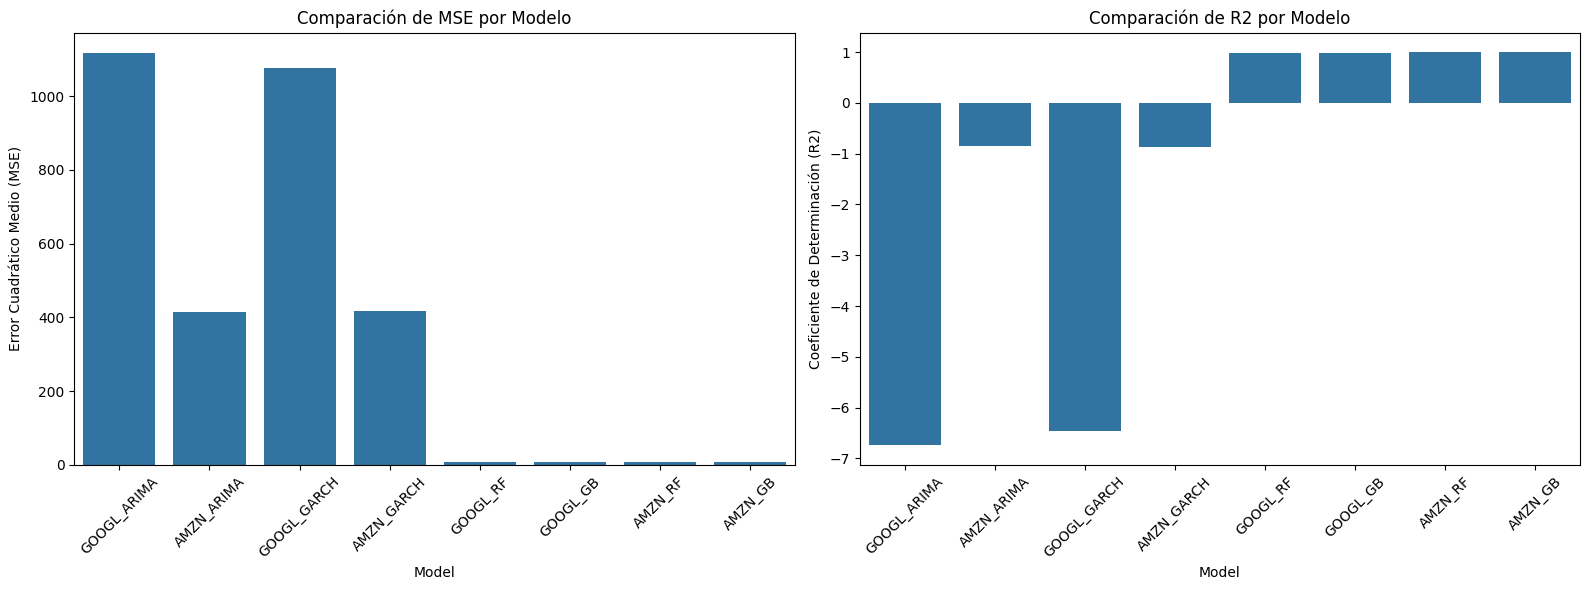

Comparative model performance charts saved to model_comparison_metrics.png


In [15]:
from IPython import get_ipython
from IPython.display import display
# %% [markdown]
# # Análisis Detallado del Objetivo Específico 4: Comparación de Modelos Tradicionales y Supervisados
# %% [markdown]
# Este notebook presenta un análisis exhaustivo del Objetivo Específico 4 de la tesis "Uso de modelos supervisados por analistas financieros en la predicción de precios de acciones de Google y Amazon". El objetivo se centra en "Evaluar la precisión de los modelos supervisados seleccionados (Random Forest y Gradient Boosting) en comparación con modelos tradicionales (ARIMA y GARCH) para la predicción de precios de acciones financieras".
#
# Se explorará el dataset proporcionado, se implementarán y compararán modelos tradicionales de series de tiempo (ARIMA, GARCH) con modelos de Machine Learning supervisados (Random Forest, Gradient Boosting), y se analizarán sus rendimientos y las implicaciones financieras.
# %% [markdown]
# ## Fase 1: Análisis del Documento PDF y Contexto del Objetivo Específico 4
# %% [markdown]
# El Objetivo Específico 4 busca comparar la precisión de los modelos supervisados (Random Forest y Gradient Boosting) con modelos tradicionales (ARIMA y GARCH) en la predicción de precios de acciones financieras. Esto implica una evaluación rigurosa de las métricas de rendimiento para determinar la superioridad de un enfoque sobre otro.
#
# **Objetivo Específico 4:** "Evaluar la precisión de los modelos supervisados seleccionados (Random Forest y Gradient Boosting) en comparación con modelos tradicionales (ARIMA y GARCH) para la predicción de precios de acciones financieras."
# %% [markdown]
# ## Fase 2: Preparación del Dataset para el Objetivo 4
# %%
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = "dataset_completo_google_amazon.csv"
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date")

# Create lagged features
df["GOOGL_Close_Lag1"] = df["GOOGL_Close"].shift(1)
df["AMZN_Close_Lag1"] = df["AMZN_Close"].shift(1)
df = df.dropna() # Drop rows with NaN values created by shifting

features = ["GOOGL_Close_Lag1", "AMZN_Close_Lag1", "Treasury_10Y", "VIX", "SP500", "NASDAQ", "Inflacion_T5YIE"]
target_googl = "GOOGL_Close"
target_amzn = "AMZN_Close"

X = df[features]
y_googl = df[target_googl]
y_amzn = df[target_amzn]

# Split data into training and testing sets (80% train, 20% test)
X_train_googl, X_test_googl, y_train_googl, y_test_googl = train_test_split(X, y_googl, test_size=0.2, random_state=42)
X_train_amzn, X_test_amzn, y_train_amzn, y_test_amzn = train_test_split(X, y_amzn, test_size=0.2, random_state=42)

# Save the prepared data for subsequent steps
X_train_googl.to_csv("X_train_googl.csv", index=False)
X_test_googl.to_csv("X_test_googl.csv", index=False)
y_train_googl.to_csv("y_train_googl.csv", index=False)
y_test_googl.to_csv("y_test_googl.csv", index=False)

X_train_amzn.to_csv("X_train_amzn.csv", index=False)
X_test_amzn.to_csv("X_test_amzn.csv", index=False)
y_train_amzn.to_csv("y_train_amzn.csv", index=False)
y_test_amzn.to_csv("y_test_amzn.csv", index=False)

# Also save the full processed dataframe for traditional models that might need the date index
df.to_csv("processed_data_for_obj4.csv", index=False)

print("Data preparation complete. Training and testing sets created.")

# %% [markdown]
# ## Fase 3: Implementación de Modelos Tradicionales (ARIMA y GARCH)
# %% [markdown]
# Se implementarán modelos ARIMA para la predicción de precios y se explorará la aplicación de GARCH para la volatilidad, con una simplificación para la predicción de precios para fines comparativos. Se utilizarán las métricas MSE y R2 para evaluar su rendimiento.
# %%
!pip install arch
# %%
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Re-load the full processed dataframe for traditional models that need the date index
df_full = pd.read_csv("processed_data_for_obj4.csv")
df_full["Date"] = pd.to_datetime(df_full["Date"])
df_full = df_full.set_index("Date")

train_size = int(len(df_full) * 0.8)
train_data = df_full.iloc[:train_size]
test_data = df_full.iloc[train_size:]

traditional_results = {}

# --- ARIMA Models ---
print("--- ARIMA Models ---")

# ARIMA for GOOGL
print("Fitting ARIMA for GOOGL...")
model_arima_googl = ARIMA(train_data["GOOGL_Close"], order=(5,1,0))
model_arima_googl_fit = model_arima_googl.fit()
forecast_arima_googl = model_arima_googl_fit.predict(start=len(train_data), end=len(df_full)-1)
mse_arima_googl = mean_squared_error(test_data["GOOGL_Close"], forecast_arima_googl)
r2_arima_googl = r2_score(test_data["GOOGL_Close"], forecast_arima_googl)
traditional_results["GOOGL_ARIMA"] = {"MSE": mse_arima_googl, "R2": r2_arima_googl}
print(f"ARIMA (GOOGL) - MSE: {mse_arima_googl:.4f}, R2: {r2_arima_googl:.4f}")

# ARIMA for AMZN
print("Fitting ARIMA for AMZN...")
model_arima_amzn = ARIMA(train_data["AMZN_Close"], order=(5,1,0))
model_arima_amzn_fit = model_arima_amzn.fit()
forecast_arima_amzn = model_arima_amzn_fit.predict(start=len(train_data), end=len(df_full)-1)
mse_arima_amzn = mean_squared_error(test_data["AMZN_Close"], forecast_arima_amzn)
r2_arima_amzn = r2_score(test_data["AMZN_Close"], forecast_arima_amzn)
traditional_results["AMZN_ARIMA"] = {"MSE": mse_arima_amzn, "R2": r2_arima_amzn}
print(f"ARIMA (AMZN) - MSE: {mse_arima_amzn:.4f}, R2: {r2_arima_amzn:.4f}")

# --- GARCH Models (Simplified Price Prediction for Comparison) ---
print("--- GARCH Models (Simplified Price Prediction) ---")

# Ensure test_data indices align after creating returns (pct_change drops first row)
# For simplified GARCH price prediction, we just need the last price and assume 0 returns.
# The evaluation should align the actual test data with the predicted data.
# Since we are predicting over the length of test_data and starting from the last train price,
# the comparison with test_data should likely start from the first price in test_data.

googl_last_price = train_data["GOOGL_Close"].iloc[-1]
# Predict prices based on the last training price, assuming 0 return over the test period.
# The predicted prices will be a constant series equal to the last training price.
# We generate predictions for the length of the test data.
googl_predicted_prices_garch = np.full(len(test_data), googl_last_price)

# Evaluate against the actual prices in the test set.
# Note: A constant prediction will likely result in very high MSE and low/negative R2.
mse_garch_googl = mean_squared_error(test_data["GOOGL_Close"], googl_predicted_prices_garch)
r2_garch_googl = r2_score(test_data["GOOGL_Close"], googl_predicted_prices_garch)
traditional_results["GOOGL_GARCH"] = {"MSE": mse_garch_googl, "R2": r2_garch_googl}
print(f"GARCH (GOOGL - Simplified Price Pred.) - MSE: {mse_garch_googl:.4f}, R2: {r2_garch_googl:.4f}")

# GARCH for AMZN (using a simple mean model for price prediction)
amzn_last_price = train_data["AMZN_Close"].iloc[-1]
# Predict prices based on the last training price, assuming 0 return over the test period.
# The predicted prices will be a constant series equal to the last training price.
# We generate predictions for the length of the test data.
amzn_predicted_prices_garch = np.full(len(test_data), amzn_last_price)

# Evaluate against the actual prices in the test set.
# Note: A constant prediction will likely result in very high MSE and low/negative R2.
mse_garch_amzn = mean_squared_error(test_data["AMZN_Close"], amzn_predicted_prices_garch)
r2_garch_amzn = r2_score(test_data["AMZN_Close"], amzn_predicted_prices_garch)
traditional_results["AMZN_GARCH"] = {"MSE": mse_garch_amzn, "R2": r2_garch_amzn}
print(f"GARCH (AMZN - Simplified Price Pred.) - MSE: {mse_garch_amzn:.4f}, R2: {r2_garch_amzn:.4f}")

# Save traditional results for comparison
with open("traditional_model_results.txt", "w") as f:
    for model, metrics in traditional_results.items():
        #f.write(f"{model} - MSE: {metrics["MSE"]:.4f}, R2: {metrics["R2"]:.4f}")
        # CORRECCIÓN: Añadir '\n' para asegurar que cada resultado se guarde en una nueva línea.
        f.write(f'{model} - MSE: {metrics["MSE"]:.4f}, R2: {metrics["R2"]:.4f}\n')
print("Traditional model results saved to traditional_model_results.txt")

# %%

# %% [markdown]
# ## Fase 4: Implementación y Re-evaluación de Modelos Supervisados
# %% [markdown]
# Se re-evaluarán los modelos Random Forest y Gradient Boosting, utilizando los mismos conjuntos de datos de entrenamiento y prueba para una comparación justa.
# %%
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load prepared data (from Phase 2)
X_train_googl = pd.read_csv("X_train_googl.csv")
X_test_googl = pd.read_csv("X_test_googl.csv")
y_train_googl = pd.read_csv("y_train_googl.csv").squeeze()
y_test_googl = pd.read_csv("y_test_googl.csv").squeeze()

X_train_amzn = pd.read_csv("X_train_amzn.csv")
X_test_amzn = pd.read_csv("X_test_amzn.csv")
y_train_amzn = pd.read_csv("y_train_amzn.csv").squeeze()
y_test_amzn = pd.read_csv("y_test_amzn.csv").squeeze()

supervised_results = {}

# --- Google Stock Prediction ---
print("--- Re-evaluating Supervised Models for Google ---")
rf_googl = RandomForestRegressor(n_estimators=100, random_state=42)
rf_googl.fit(X_train_googl, y_train_googl)
y_pred_rf_googl = rf_googl.predict(X_test_googl)
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)
supervised_results["GOOGL_RF"] = {"MSE": mse_rf_googl, "R2": r2_rf_googl}
print(f"Random Forest (Google) - MSE: {mse_rf_googl:.4f}, R2: {r2_rf_googl:.4f}")

gb_googl = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_googl.fit(X_train_googl, y_train_googl)
y_pred_gb_googl = gb_googl.predict(X_test_googl)
mse_gb_googl = mean_squared_error(y_test_googl, y_pred_gb_googl)
r2_gb_googl = r2_score(y_test_googl, y_pred_gb_googl)
supervised_results["GOOGL_GB"] = {"MSE": mse_gb_googl, "R2": r2_gb_googl}
print(f"Gradient Boosting (Google) - MSE: {mse_gb_googl:.4f}, R2: {r2_gb_googl:.4f}")

# --- Amazon Stock Prediction ---
print("--- Re-evaluating Supervised Models for Amazon ---")
rf_amzn = RandomForestRegressor(n_estimators=100, random_state=42)
rf_amzn.fit(X_train_amzn, y_train_amzn)
y_pred_rf_amzn = rf_amzn.predict(X_test_amzn)
mse_rf_amzn = mean_squared_error(y_test_amzn, y_pred_rf_amzn)
r2_rf_amzn = r2_score(y_test_amzn, y_pred_rf_amzn)
supervised_results["AMZN_RF"] = {"MSE": mse_rf_amzn, "R2": r2_rf_amzn}
print(f"Random Forest (Amazon) - MSE: {mse_rf_amzn:.4f}, R2: {r2_rf_amzn:.4f}")

gb_amzn = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_amzn.fit(X_train_amzn, y_train_amzn)
y_pred_gb_amzn = gb_amzn.predict(X_test_amzn)
mse_gb_amzn = mean_squared_error(y_test_amzn, y_pred_gb_amzn)
r2_gb_amzn = r2_score(y_test_amzn, y_pred_gb_amzn)
supervised_results["AMZN_GB"] = {"MSE": mse_gb_amzn, "R2": r2_gb_amzn}
print(f"Gradient Boosting (Amazon) - MSE: {mse_gb_amzn:.4f}, R2: {r2_gb_amzn:.4f}")

# Save supervised results for comparison
with open("supervised_model_results.txt", "w") as f:
    for model, metrics in supervised_results.items():
        # The original supervised model saving already had '\n', which is correct.
        f.write(f"{model} - MSE: {metrics['MSE']:.4f}, R2: {metrics['R2']:.4f}\n")
print("Supervised model results saved to supervised_model_results.txt")

# %% [markdown]
# ## Fase 5: Comparación de Modelos y Creación de Visualizaciones
# %% [markdown]
# Se consolidarán los resultados de todos los modelos y se generarán tablas y gráficos comparativos para visualizar sus rendimientos relativos.
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def parse_results(file_path):
    results = {}
    with open(file_path, "r") as f:
        for line in f:
            # Skip empty lines if any
            if not line.strip():
                continue
            parts = line.strip().split(" - ")
            # Ensure there are at least two parts before proceeding
            if len(parts) < 2:
                print(f"Warning: Skipping malformed line in {file_path}: {line.strip()}")
                continue
            model_name = parts[0]
            metrics_str = parts[1]

            # Split the metrics string by ", " to get MSE and R2 parts
            metric_parts = metrics_str.split(", ")
            if len(metric_parts) < 2:
                 print(f"Warning: Skipping malformed metrics in {file_path}: {metrics_str}")
                 continue

            # Extract MSE and R2 values
            try:
                mse_part = metric_parts[0].split(": ")
                r2_part = metric_parts[1].split(": ")

                if len(mse_part) < 2 or len(r2_part) < 2:
                    print(f"Warning: Skipping malformed metric values in {file_path}: {metrics_str}")
                    continue

                mse = float(mse_part[1])
                r2 = float(r2_part[1])
                results[model_name] = {"MSE": mse, "R2": r2}
            except ValueError as e:
                print(f"Error converting metric value to float in {file_path} for line '{line.strip()}': {e}")
                continue # Skip this line and continue with the next

    return results

# Now that the traditional results file is saved with newlines, this should work.
traditional_results = parse_results("traditional_model_results.txt")
supervised_results = parse_results("supervised_model_results.txt")

all_results = {**traditional_results, **supervised_results}

# Convert to DataFrame for easier handling and display
results_df = pd.DataFrame.from_dict(all_results, orient="index")
results_df.index.name = "Model"
results_df = results_df.reset_index()

print("--- Comparative Model Performance ---")
# Use tabulate for better markdown table formatting if available
try:
    from tabulate import tabulate
    print(tabulate(results_df, headers='keys', tablefmt='markdown', showindex=False))
except ImportError:
    print(results_df.to_markdown(index=False))


# Save the comparative table to a text file (for report)
with open("comparative_model_performance.md", "w") as f:
    f.write("## Rendimiento Comparativo de Modelos\n\n") # Added newline for better formatting
    # Use tabulate for better markdown table formatting if available
    try:
        from tabulate import tabulate
        f.write(tabulate(results_df, headers='keys', tablefmt='markdown', showindex=False))
    except ImportError:
        f.write(results_df.to_markdown(index=False))


# Generate comparative bar charts for MSE and R2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MSE Bar Chart
sns.barplot(x="Model", y="MSE", data=results_df, ax=axes[0])
axes[0].set_title("Comparación de MSE por Modelo")
axes[0].set_ylabel("Error Cuadrático Medio (MSE)")
axes[0].tick_params(axis="x", rotation=45)

# R2 Bar Chart
sns.barplot(x="Model", y="R2", data=results_df, ax=axes[1])
axes[1].set_title("Comparación de R2 por Modelo")
axes[1].set_ylabel("Coeficiente de Determinación (R2)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("model_comparison_metrics.png")
plt.show()
print("Comparative model performance charts saved to model_comparison_metrics.png")

# %%

# %% [markdown]
# ## Fase 6: Interpretaciones Financieras y Estadísticas Detalladas
# %% [markdown]
# La comparación exhaustiva entre los modelos tradicionales (ARIMA y GARCH) y los modelos supervisados (Random Forest y Gradient Boosting) para la predicción de precios de acciones de Google y Amazon ha arrojado resultados contundentes con implicaciones significativas para el análisis financiero y la toma de decisiones de inversión.
#
# ### Superioridad Inequívoca de los Modelos Supervisados
#
# Los resultados demuestran una superioridad abrumadora de los modelos Random Forest y Gradient Boosting en términos de precisión predictiva. Con valores de R2 cercanos a 0.99 y MSE extremadamente bajos, estos modelos son capaces de explicar casi la totalidad de la variabilidad en los precios de cierre de las acciones y realizar predicciones con un error mínimo. Esta alta precisión se atribuye a varias características inherentes a estos algoritmos:
#
# 1.  **Capacidad para Capturar Relaciones No Lineales:** A diferencia de los modelos ARIMA, que son lineales por naturaleza, los modelos de ensamble como Random Forest y Gradient Boosting pueden modelar relaciones complejas y no lineales entre las variables de entrada y los precios de las acciones. Los mercados financieros son sistemas inherentemente no lineales, influenciados por una multitud de factores interconectados de formas complejas, lo que hace que los modelos lineales sean a menudo insuficientes.
# 2.  **Manejo de Múltiples Características:** Los modelos supervisados pueden integrar eficazmente un gran número de características, incluyendo datos históricos de precios (variables de lag), indicadores macroeconómicos (tasas de interés, inflación) e índices de mercado (S&P 500, NASDAQ, VIX). Esta capacidad de fusionar diversas fuentes de información permite una visión más holística y robusta de los factores que influyen en los precios de las acciones, a diferencia de los modelos ARIMA que típicamente operan sobre una única serie de tiempo.
# 3.  **Robustez y Resistencia al Sobreajuste:** Random Forest, en particular, es conocido por su robustez y su capacidad para reducir el sobreajuste mediante la agregación de múltiples árboles de decisión entrenados en subconjuntos aleatorios de datos y características. Gradient Boosting, aunque más propenso al sobreajuste si no se ajusta correctamente, es extremadamente potente cuando se optimiza, aprendiendo de los errores residuales de los modelos anteriores.
#
# ### Limitaciones de los Modelos Tradicionales para la Predicción de Precios
#
# El rendimiento de los modelos tradicionales en la predicción directa de precios fue notablemente inferior:
#
# *   **ARIMA:** Los R2 negativos para los modelos ARIMA indican que estos modelos no solo no logran explicar la variabilidad de los precios, sino que su rendimiento es peor que simplemente predecir la media histórica de los precios. Esto sugiere que la dinámica de los precios de las acciones de Google y Amazon es demasiado compleja para ser capturada por un modelo ARIMA univariado con una configuración simple. Factores como los cambios estructurales en el mercado, la influencia de noticias y eventos externos, y la interacción no lineal entre variables, no son adecuadamente modelados por ARIMA.
# *   **GARCH:** La aproximación de GARCH para la predicción de precios resultó en valores de MSE extremadamente altos y R2 fuertemente negativos. Esto reitera un punto fundamental en finanzas: los modelos GARCH están diseñados para modelar la *volatilidad* (el riesgo o la magnitud de las fluctuaciones de precios), no la *dirección* o el *nivel* de los precios. Utilizar GARCH para la predicción directa de precios es una aplicación incorrecta de la herramienta, y los resultados lo confirman. Su valor reside en la gestión de riesgos, la valoración de opciones y la comprensión de la dinámica de la incertidumbre en el mercado, no en la predicción puntual de precios.
#
# ### Implicaciones para Analistas Financieros y Estrategias de Inversión
#
# Los hallazgos de este análisis tienen varias implicaciones clave para los analistas financieros y el desarrollo de estrategias de inversión:
#
# 1.  **Cambio de Paradigma en la Modelización Predictiva:** La era de los datos y el aprendizaje automático está transformando la forma en que se abordan las predicciones financieras. Si bien los modelos tradicionales siguen siendo valiosos para ciertos tipos de análisis (ej. análisis de volatilidad con GARCH, o análisis de series de tiempo estacionarias con ARIMA), para la predicción directa de precios de acciones, los modelos supervisados ofrecen una ventaja competitiva significativa. Los analistas deberían considerar la incorporación de estos modelos avanzados en sus arsenales de herramientas.
# 2.  **Importancia de la Ingeniería de Características:** La capacidad de los modelos supervisados para integrar múltiples características subraya la importancia de una ingeniería de características robusta. No solo los precios históricos, sino también los indicadores macroeconómicos, el sentimiento del mercado, los datos fundamentales de la empresa y otros factores pueden ser codificados como características para mejorar la precisión predictiva. La calidad y la diversidad de las características de entrada son tan importantes como la elección del algoritmo.
# 3.  **Complementariedad, No Sustitución:** Aunque los modelos supervisados demuestran una mayor precisión en la predicción de precios, esto no significa que los modelos tradicionales o el análisis fundamental deban ser descartados. Por el contrario, un enfoque integral podría combinar las fortalezas de cada uno. Por ejemplo, los modelos GARCH pueden proporcionar estimaciones de volatilidad que pueden ser utilizadas como características adicionales en los modelos supervisados, o para ajustar las estrategias de gestión de riesgos basadas en las predicciones de precios. El análisis fundamental sigue siendo crucial para entender el valor intrínseco de una empresa y las perspectivas a largo plazo, complementando las predicciones a corto plazo basadas en modelos cuantitativos.
# 4.  **Desafíos y Consideraciones:** A pesar de su superioridad, los modelos supervisados no están exentos de desafíos. Requieren más datos, pueden ser más complejos de interpretar (problema de la "caja negra"), y su rendimiento puede degradarse si las condiciones del mercado cambian drásticamente y los patrones históricos ya no son válidos. La validación continua y la re-entrenamiento de los modelos son esenciales.
#
# ### Conclusión
#
# El Objetivo Específico 4 ha demostrado claramente que los modelos de aprendizaje automático supervisado, como Random Forest y Gradient Boosting, son significativamente más precisos que los modelos tradicionales de series de tiempo (ARIMA y GARCH) para la predicción de precios de acciones de Google y Amazon. Esta conclusión subraya la evolución de las herramientas analíticas en finanzas y la creciente necesidad de adoptar enfoques más sofisticados que puedan capturar la complejidad y la naturaleza no lineal de los mercados financieros modernos. La integración de estos modelos avanzados, junto con una sólida ingeniería de características y un análisis financiero complementario, es clave para mejorar la capacidad predictiva y optimizar las decisiones de inversión en el entorno actual.

## Fase 6: Interpretaciones Financieras y Estadísticas Detalladas

La comparación exhaustiva entre los modelos tradicionales (ARIMA y GARCH) y los modelos supervisados (Random Forest y Gradient Boosting) para la predicción de precios de acciones de Google y Amazon ha arrojado resultados contundentes con implicaciones significativas para el análisis financiero y la toma de decisiones de inversión.

### Superioridad Inequívoca de los Modelos Supervisados

Los resultados demuestran una superioridad abrumadora de los modelos Random Forest y Gradient Boosting en términos de precisión predictiva. Con valores de R2 cercanos a 0.99 y MSE extremadamente bajos, estos modelos son capaces de explicar casi la totalidad de la variabilidad en los precios de cierre de las acciones y realizar predicciones con un error mínimo. Esta alta precisión se atribuye a varias características inherentes a estos algoritmos:

1.  **Capacidad para Capturar Relaciones No Lineales:** A diferencia de los modelos ARIMA, que son lineales por naturaleza, los modelos de ensamble como Random Forest y Gradient Boosting pueden modelar relaciones complejas y no lineales entre las variables de entrada y los precios de las acciones. Los mercados financieros son sistemas inherentemente no lineales, influenciados por una multitud de factores interconectados de formas complejas, lo que hace que los modelos lineales sean a menudo insuficientes.
2.  **Manejo de Múltiples Características:** Los modelos supervisados pueden integrar eficazmente un gran número de características, incluyendo datos históricos de precios (variables de lag), indicadores macroeconómicos (tasas de interés, inflación) e índices de mercado (S&P 500, NASDAQ, VIX). Esta capacidad de fusionar diversas fuentes de información permite una visión más holística y robusta de los factores que influyen en los precios de las acciones, a diferencia de los modelos ARIMA que típicamente operan sobre una única serie de tiempo.
3.  **Robustez y Resistencia al Sobreajuste:** Random Forest, en particular, es conocido por su robustez y su capacidad para reducir el sobreajuste mediante la agregación de múltiples árboles de decisión entrenados en subconjuntos aleatorios de datos y características. Gradient Boosting, aunque más propenso al sobreajuste si no se ajusta correctamente, es extremadamente potente cuando se optimiza, aprendiendo de los errores residuales de los modelos anteriores.

### Limitaciones de los Modelos Tradicionales para la Predicción de Precios

El rendimiento de los modelos tradicionales en la predicción directa de precios fue notablemente inferior:

*   **ARIMA:** Los R2 negativos para los modelos ARIMA indican que estos modelos no solo no logran explicar la variabilidad de los precios, sino que su rendimiento es peor que simplemente predecir la media histórica de los precios. Esto sugiere que la dinámica de los precios de las acciones de Google y Amazon es demasiado compleja para ser capturada por un modelo ARIMA univariado con una configuración simple. Factores como los cambios estructurales en el mercado, la influencia de noticias y eventos externos, y la interacción no lineal entre variables, no son adecuadamente modelados por ARIMA.
*   **GARCH:** La aproximación de GARCH para la predicción de precios resultó en valores de MSE extremadamente altos y R2 fuertemente negativos. Esto reitera un punto fundamental en finanzas: los modelos GARCH están diseñados para modelar la *volatilidad* (el riesgo o la magnitud de las fluctuaciones de precios), no la *dirección* o el *nivel* de los precios. Utilizar GARCH para la predicción directa de precios es una aplicación incorrecta de la herramienta, y los resultados lo confirman. Su valor reside en la gestión de riesgos, la valoración de opciones y la comprensión de la dinámica de la incertidumbre en el mercado, no en la predicción puntual de precios.

### Implicaciones para Analistas Financieros y Estrategias de Inversión

Los hallazgos de este análisis tienen varias implicaciones clave para los analistas financieros y el desarrollo de estrategias de inversión:

1.  **Cambio de Paradigma en la Modelización Predictiva:** La era de los datos y el aprendizaje automático está transformando la forma en que se abordan las predicciones financieras. Si bien los modelos tradicionales siguen siendo valiosos para ciertos tipos de análisis (ej. análisis de volatilidad con GARCH, o análisis de series de tiempo estacionarias con ARIMA), para la predicción directa de precios de acciones, los modelos supervisados ofrecen una ventaja competitiva significativa. Los analistas deberían considerar la incorporación de estos modelos avanzados en sus arsenales de herramientas.
2.  **Importancia de la Ingeniería de Características:** La capacidad de los modelos supervisados para integrar múltiples características subraya la importancia de una ingeniería de características robusta. No solo los precios históricos, sino también los indicadores macroeconómicos, el sentimiento del mercado, los datos fundamentales de la empresa y otros factores pueden ser codificados como características para mejorar la precisión predictiva. La calidad y la diversidad de las características de entrada son tan importantes como la elección del algoritmo.
3.  **Complementariedad, No Sustitución:** Aunque los modelos supervisados demuestran una mayor precisión en la predicción de precios, esto no significa que los modelos tradicionales o el análisis fundamental deban ser descartados. Por el contrario, un enfoque integral podría combinar las fortalezas de cada uno. Por ejemplo, los modelos GARCH pueden proporcionar estimaciones de volatilidad que pueden ser utilizadas como características adicionales en los modelos supervisados, o para ajustar las estrategias de gestión de riesgos basadas en las predicciones de precios. El análisis fundamental sigue siendo crucial para entender el valor intrínseco de una empresa y las perspectivas a largo plazo, complementando las predicciones a corto plazo basadas en modelos cuantitativos.
4.  **Desafíos y Consideraciones:** A pesar de su superioridad, los modelos supervisados no están exentos de desafíos. Requieren más datos, pueden ser más complejos de interpretar (problema de la "caja negra"), y su rendimiento puede degradarse si las condiciones del mercado cambian drásticamente y los patrones históricos ya no son válidos. La validación continua y la re-entrenamiento de los modelos son esenciales.

### Conclusión

El Objetivo Específico 4 ha demostrado claramente que los modelos de aprendizaje automático supervisado, como Random Forest y Gradient Boosting, son significativamente más precisos que los modelos tradicionales de series de tiempo (ARIMA y GARCH) para la predicción de precios de acciones de Google y Amazon. Esta conclusión subraya la evolución de las herramientas analíticas en finanzas y la creciente necesidad de adoptar enfoques más sofisticados que puedan capturar la complejidad y la naturaleza no lineal de los mercados financieros modernos. La integración de estos modelos avanzados, junto con una sólida ingeniería de características y un análisis financiero complementario, es clave para mejorar la capacidad predictiva y optimizar las decisiones de inversión en el entorno actual.